[[ 0.72931958  0.2798805 ]
 [ 0.0397876  -0.75035876]
 [-0.70763439 -0.38693263]
 ...
 [ 0.26802416 -0.99650988]
 [-0.41926083  0.72650975]
 [-0.40339342 -0.67024324]]


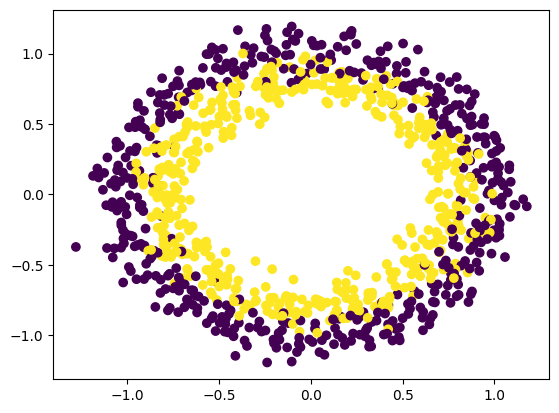

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.09, random_state=12)

print(X)
plt.scatter(X[:, 0], X[:, 1], c=y)

In [2]:
# data to tensors

import torch
from sklearn.model_selection import train_test_split


X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

## Splitting data
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=.2,
                                                    random_state=4)

X_train[:5], y_train[:5]

(tensor([[-0.4582,  0.9297],
         [-0.5441,  0.6024],
         [-0.4681, -0.9751],
         [ 0.7463,  0.0046],
         [-0.4628, -0.4120]]),
 tensor([0., 1., 0., 1., 1.]))

#### Model Building

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [4]:
from torch import nn

class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2, out_features=10)
        self.layer_2=nn.Linear(in_features=10, out_features=10)
        self.layer_3=nn.Linear(in_features=10, out_features=1)
        self.relu=nn.ReLU()

    def forward(self, X):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(X)))))

model = ClassificationModel().to(device)
model

ClassificationModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [5]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)


In [6]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [7]:
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.0550,  0.6627],
                      [ 0.2772, -0.6908],
                      [-0.4737, -0.1520],
                      [-0.5325, -0.5940],
                      [-0.2592,  0.3576],
                      [ 0.3974,  0.4344],
                      [-0.1688, -0.0457],
                      [ 0.5220, -0.0822],
                      [-0.0037,  0.1957],
                      [-0.3913, -0.2434]])),
             ('layer_1.bias',
              tensor([-0.3748,  0.3394,  0.3660, -0.4326, -0.4622,  0.5780, -0.5197,  0.0997,
                      -0.3667,  0.2156])),
             ('layer_2.weight',
              tensor([[ 4.1690e-02,  1.0707e-02,  2.2737e-01,  2.0364e-01, -8.4617e-02,
                       -1.3455e-01, -2.3506e-01,  1.7794e-02,  9.6031e-02, -1.1988e-01],
                      [-3.8508e-02, -2.7970e-01, -1.1528e-01, -3.0795e-01, -2.3503e-01,
                        3.0020e-01, -1.9924e-01,  2.2180e-01, -2.3337e-01,  4.170

In [8]:
def train_model(model: nn.Module,
                data: torch.Tensor,
                targets: torch.Tensor, 
                loss_fn,
                optimizer, EPOCHS):
    
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)

    for epoch in range(EPOCHS):
        model.train()

        # 1. Forward pass
        logits = model(data).squeeze()
        y_pred = torch.round(torch.sigmoid(logits))

        # 2. Calculate loss
        loss = loss_fn(logits, targets)
        acc = accuracy_fn(targets, y_pred)

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Backpropagation
        loss.backward()

        # 5. Step the optimizer
        optimizer.step()

        # testing
        model.eval()
    
        with torch.inference_mode():
            test_logits = model(X_test.to(device)).squeeze()
            test_pred = torch.round(torch.sigmoid(test_logits))
            test_loss = loss_fn(test_logits, y_test.to(device))
            test_acc = accuracy_fn(y_test.to(device), test_pred)
        if epoch % 100 == 0:
            print(f'Epoch: {epoch} | Train Loss: {loss:.4f} | Train Accuracy: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%')

In [9]:
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.0550,  0.6627],
                      [ 0.2772, -0.6908],
                      [-0.4737, -0.1520],
                      [-0.5325, -0.5940],
                      [-0.2592,  0.3576],
                      [ 0.3974,  0.4344],
                      [-0.1688, -0.0457],
                      [ 0.5220, -0.0822],
                      [-0.0037,  0.1957],
                      [-0.3913, -0.2434]])),
             ('layer_1.bias',
              tensor([-0.3748,  0.3394,  0.3660, -0.4326, -0.4622,  0.5780, -0.5197,  0.0997,
                      -0.3667,  0.2156])),
             ('layer_2.weight',
              tensor([[ 4.1690e-02,  1.0707e-02,  2.2737e-01,  2.0364e-01, -8.4617e-02,
                       -1.3455e-01, -2.3506e-01,  1.7794e-02,  9.6031e-02, -1.1988e-01],
                      [-3.8508e-02, -2.7970e-01, -1.1528e-01, -3.0795e-01, -2.3503e-01,
                        3.0020e-01, -1.9924e-01,  2.2180e-01, -2.3337e-01,  4.170

#### Training Model

In [10]:
EPOCHS = 1000
train_model(model=model, data=X, targets=y, loss_fn=loss_fn, optimizer=optimizer, EPOCHS=EPOCHS)

Epoch: 0 | Train Loss: 0.6948 | Train Accuracy: 50.00% | Test Loss: 0.6914 | Test Accuracy: 50.50%
Epoch: 100 | Train Loss: 0.6894 | Train Accuracy: 56.40% | Test Loss: 0.6865 | Test Accuracy: 63.50%
Epoch: 200 | Train Loss: 0.6858 | Train Accuracy: 62.00% | Test Loss: 0.6830 | Test Accuracy: 69.00%
Epoch: 300 | Train Loss: 0.6804 | Train Accuracy: 64.30% | Test Loss: 0.6780 | Test Accuracy: 68.50%
Epoch: 400 | Train Loss: 0.6717 | Train Accuracy: 70.50% | Test Loss: 0.6701 | Test Accuracy: 73.50%
Epoch: 500 | Train Loss: 0.6573 | Train Accuracy: 76.50% | Test Loss: 0.6564 | Test Accuracy: 76.50%
Epoch: 600 | Train Loss: 0.6326 | Train Accuracy: 79.20% | Test Loss: 0.6318 | Test Accuracy: 77.50%
Epoch: 700 | Train Loss: 0.5899 | Train Accuracy: 83.40% | Test Loss: 0.5847 | Test Accuracy: 83.50%
Epoch: 800 | Train Loss: 0.5254 | Train Accuracy: 84.90% | Test Loss: 0.5143 | Test Accuracy: 83.50%
Epoch: 900 | Train Loss: 0.4492 | Train Accuracy: 86.70% | Test Loss: 0.4349 | Test Accuracy:

#### Evaluating Model

In [11]:
model.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model(X_test))).squeeze()

y_preds[:10], y_test[:10]

(tensor([0., 1., 1., 1., 0., 0., 1., 0., 1., 0.]),
 tensor([0., 1., 1., 1., 1., 0., 1., 0., 1., 0.]))

In [12]:
import numpy as np

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.
    """
    
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

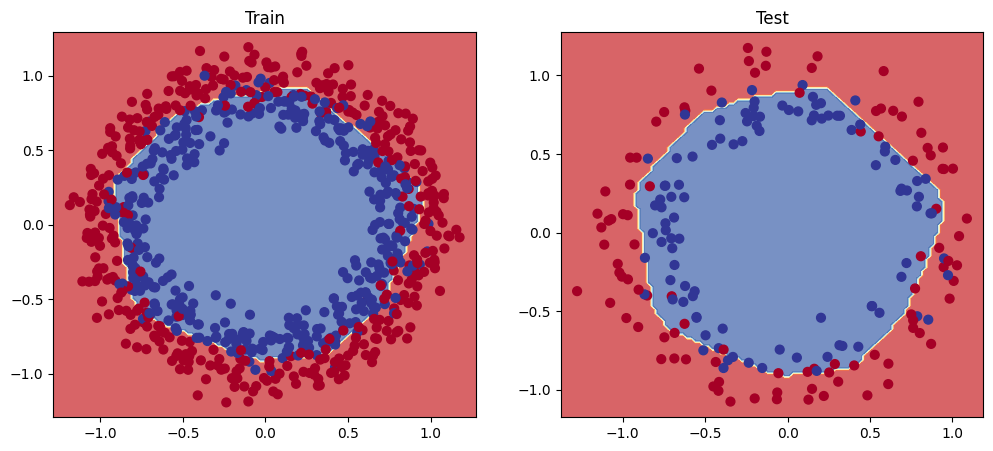

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)


In [14]:
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.0788,  1.3172],
                      [ 0.6874, -1.2424],
                      [-0.8361, -0.1264],
                      [-0.9127, -0.9415],
                      [-1.0490,  0.7622],
                      [ 0.8859,  0.8694],
                      [-0.1688, -0.0457],
                      [ 1.1034, -0.2082],
                      [-0.0037,  0.1957],
                      [-0.8125, -0.4861]])),
             ('layer_1.bias',
              tensor([-0.2206, -0.2776, -0.1169, -0.5112, -0.4867, -0.1566, -0.5197, -0.0929,
                      -0.3667, -0.0576])),
             ('layer_2.weight',
              tensor([[-0.1323, -0.1747,  0.1346, -0.0120, -0.2486, -0.2287, -0.2351, -0.1554,
                        0.0960, -0.2404],
                      [-0.2425, -0.3438, -0.0938, -0.4296, -0.4310,  0.1722, -0.1992,  0.0370,
                       -0.2334,  0.0412],
                      [-0.0253, -0.1692, -0.2392, -0.1356,  0.0359,  0.5

### Saving model


In [15]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "02_PYTORCH_CLASSIFICATION_MODEL.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f" Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)


 Saving model to: models\02_PYTORCH_CLASSIFICATION_MODEL.pth


### Loading Saved Model


In [17]:
load_model = ClassificationModel()

print(f'Loading model from: {MODEL_SAVE_PATH}')
load_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

load_model.state_dict()

Loading model from: models\02_PYTORCH_CLASSIFICATION_MODEL.pth


OrderedDict([('layer_1.weight',
              tensor([[ 0.0788,  1.3172],
                      [ 0.6874, -1.2424],
                      [-0.8361, -0.1264],
                      [-0.9127, -0.9415],
                      [-1.0490,  0.7622],
                      [ 0.8859,  0.8694],
                      [-0.1688, -0.0457],
                      [ 1.1034, -0.2082],
                      [-0.0037,  0.1957],
                      [-0.8125, -0.4861]])),
             ('layer_1.bias',
              tensor([-0.2206, -0.2776, -0.1169, -0.5112, -0.4867, -0.1566, -0.5197, -0.0929,
                      -0.3667, -0.0576])),
             ('layer_2.weight',
              tensor([[-0.1323, -0.1747,  0.1346, -0.0120, -0.2486, -0.2287, -0.2351, -0.1554,
                        0.0960, -0.2404],
                      [-0.2425, -0.3438, -0.0938, -0.4296, -0.4310,  0.1722, -0.1992,  0.0370,
                       -0.2334,  0.0412],
                      [-0.0253, -0.1692, -0.2392, -0.1356,  0.0359,  0.5

#### Testing model

In [18]:
load_model.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(load_model(X_test))).squeeze()
    loss = loss_fn(y_test, y_preds)
    accuracy = accuracy_fn(y_test.to(device), y_preds.to(device))
print(y_preds[:10])
print(f'Accuracy: {accuracy}')
print(f'Loss: {loss}')

tensor([0., 1., 1., 1., 0., 0., 1., 0., 1., 0.])
Accuracy: 85.5
Loss: 0.5763050317764282


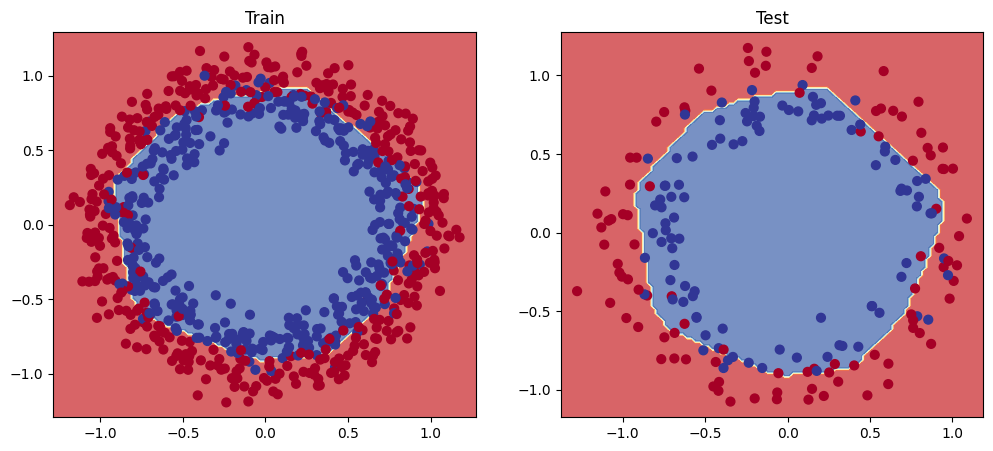

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(load_model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(load_model, X_test, y_test)


In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_preds)
print(f'Precision Score: {precision}')

recall = recall_score(y_test, y_preds)
print(f'Recall Score: {recall}')

f1_score = f1_score(y_test, y_preds)
print(f'F1 Score: {f1_score}')

Precision Score: 0.86
Recall Score: 0.8514851485148515
F1 Score: 0.8557213930348259
